In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import sys
import os
import numpy as np
import time
import simpy
import collections
from scipy.stats import sem, t
import contextlib
import io

# 1. SETUP PATHS FIRST
# sys.path.append('../pkls')
sys.path.append('butools2/Python')
sys.path.append('sim_course_pycharm')

# 2. IMPORT CUSTOM MODULES (Now Python knows where to find them)
import butools
from butools.fitting import PHFromTrace
from butools.ph import SamplesFromPH
from utils import compute_pdf_within_range, compute_first_n_moments
from project import Queue_open_network_markov_trans, give_CI_length
from project_utils import give_transeint_probs

# 3. LOAD DATA LAST
pkl_path = 'pkls/df_data_group_5.pkl' 
df_events_all_stations = pkl.load(open(pkl_path, 'rb'))

ptrans_path = 'pkls/ptrans_group_5.pkl' 
p_trans = pkl.load(open(ptrans_path, 'rb'))

scd_path = 'pkls/arrival_sch_group_5.pkl' 
arrival_scd_pd = pkl.load(open(scd_path, 'rb'))

In [95]:
p_trans

array([[0.        , 0.26022469, 0.        ],
       [0.        , 0.        , 0.26587276],
       [0.        , 0.08710111, 0.        ]])

In [116]:
df_events_all_stations[0].head(3), df_events_all_stations[1].head(3), df_events_all_stations[2].head(3)

(   Customer          Event      Time
 0         3        Arrival  0.188043
 1         3  Enter service  0.188043
 2         6        Arrival  0.398950,
    Customer          Event      Time
 0         1        Arrival  0.003553
 1         1  Enter service  0.003553
 2         4        Arrival  0.223289,
    Customer          Event      Time
 0         2        Arrival  0.064297
 1         2  Enter service  0.064297
 2         2      Departure  0.174182)

# Q1

--- Processing: Junior Inter-Arrivals ---


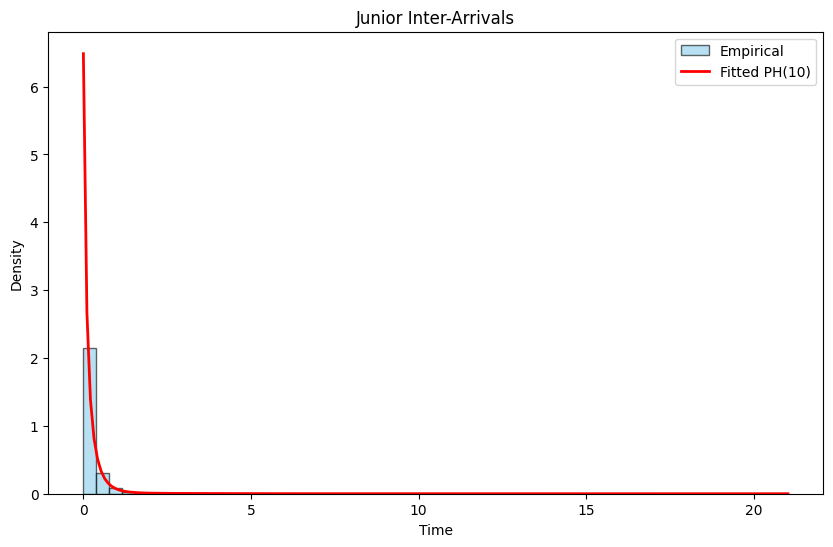

--- Processing: Junior Service ---


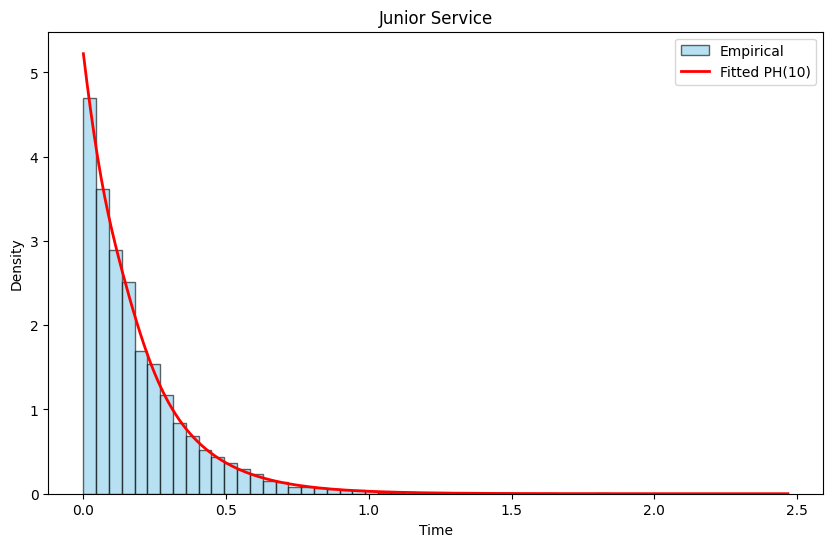

--- Processing: Senior Service ---


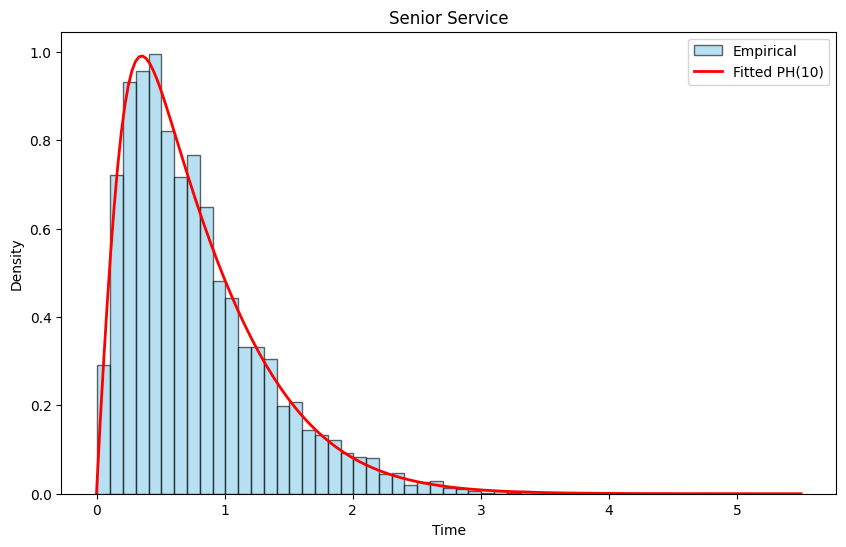

--- Processing: Manager Service ---


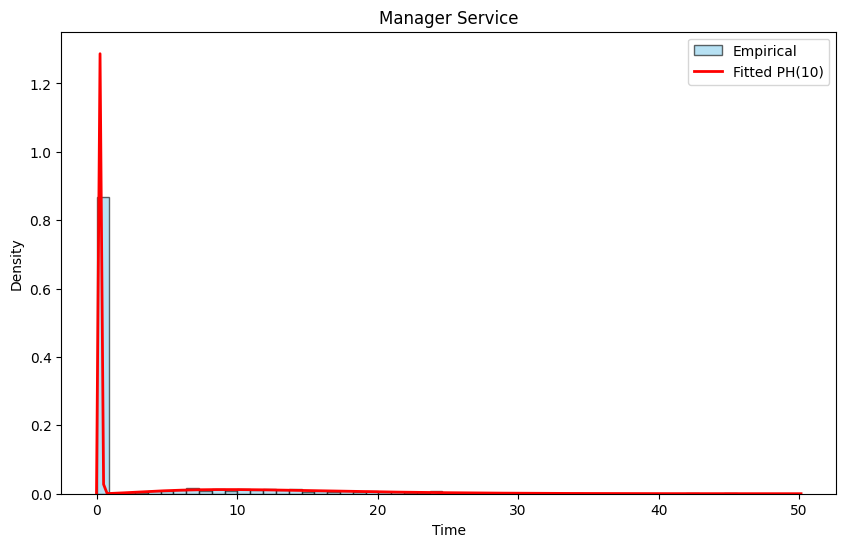

In [98]:
# --- 1. Define Extraction Helpers (Keep these, they don't exist elsewhere) ---
# def get_service_times(df):
#     enters = df[df['Event'] == 'Enter service'].set_index('Customer')['Time']
#     departs = df[df['Event'] == 'Departure'].set_index('Customer')['Time']
#     return (departs - enters).dropna().values

def get_service_times(df):
    # Ensure the dataframe is sorted chronologically
    df = df.sort_values('Time')
    
    enters = df[df['Event'] == 'Enter service']['Time'].values
    departs = df[df['Event'] == 'Departure']['Time'].values
    
    # Find the minimum length to handle customers left in service at the end of the simulation
    min_len = min(len(enters), len(departs))
    
    # Subtract only the paired events
    return departs[:min_len] - enters[:min_len]


def get_inter_arrival_times(df):
    arrivals = df[df['Event'] == 'Arrival'].sort_values('Time')['Time']
    return arrivals.diff().dropna().values


# --- 2. Refactored Analysis Function ---
def analyze_and_plot(data, title, ph_size=10):
    print(f"--- Processing: {title} ---")
    
    # Fit the data
    # PHFromTrace returns 3 values: (alpha, S, log_likelihood)
    # We use '_' to capture and ignore the log_likelihood
    alpha, S, _ = PHFromTrace(data, ph_size)
    
    # Convert to numpy arrays for safety with the utils function
    alpha = np.array(alpha).flatten()
    S = np.array(S)
    
    # Set up X-axis range
    x_max = np.max(data) * 1.1
    x_vals = np.linspace(0, x_max, 200)
    
    # Use util function to calculate PDF
    y_vals = compute_pdf_within_range(x_vals, alpha, S)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.hist(data, density=True, bins=50, alpha=0.6, color='skyblue', label='Empirical', edgecolor='black')
    plt.plot(x_vals, y_vals, 'r-', lw=2, label=f'Fitted PH({ph_size})')
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
    
    return alpha, S

# --- 3. Execution ---
# Load data
junior_data = df_events_all_stations[0]
senior_data = df_events_all_stations[1]
manager_data = df_events_all_stations[2]

# Run analysis
alpha_junior_arr, S_junior_arr = analyze_and_plot(get_inter_arrival_times(junior_data), "Junior Inter-Arrivals")
alpha_junior_srv, S_junior_srv = analyze_and_plot(get_service_times(junior_data), "Junior Service")
alpha_senior_srv, S_senior_srv = analyze_and_plot(get_service_times(senior_data), "Senior Service")
alpha_manager_srv, S_manager_srv = analyze_and_plot(get_service_times(manager_data), "Manager Service")

# Q2

In [99]:
# --- 1. Calculate Mean Times using fitted PH parameters from Q1 ---

# Calculate Inter-Arrival Mean (1st moment)
mean_inter_arrival_junior = compute_first_n_moments(alpha_junior_arr, S_junior_arr, 1)[0]

# Calculate Service Means (1st moment)
mean_service_junior = compute_first_n_moments(alpha_junior_srv, S_junior_srv, 1)[0]
mean_service_senior = compute_first_n_moments(alpha_senior_srv, S_senior_srv, 1)[0]
mean_service_manager = compute_first_n_moments(alpha_manager_srv, S_manager_srv, 1)[0]

# --- 2. Calculate External Lambda ---
lambda_external = 1.0 / mean_inter_arrival_junior

# --- 3. Extract Transition Probabilities ---
p12 = p_trans[0, 1]  # Junior -> Senior
p23 = p_trans[1, 2]  # Senior -> Manager
p32 = p_trans[2, 1]  # Manager -> Senior

# --- 4. Flow Balance Equations (Analytical Solution) ---
# Solve for arrival rates (lambdas) at each station
lambda_1 = lambda_external
lambda_2 = (lambda_1 * p12) / (1 - (p23 * p32))
lambda_3 = lambda_2 * p23

# --- 5. Calculate Utilizations (rho) ---
rho_junior = lambda_1 * mean_service_junior
rho_senior = lambda_2 * mean_service_senior
rho_manager = lambda_3 * mean_service_manager

print("--- Analytical Utilizations (Based on Fitted PH) ---")
print(f"Junior Station: {rho_junior:.4f}")
print(f"Senior Station: {rho_senior:.4f}")
print(f"Manager Station: {rho_manager:.4f}")

--- Analytical Utilizations (Based on Fitted PH) ---
Junior Station: 0.6973
Senior Station: 0.7568
Manager Station: 0.7833


# Q3

In [101]:
# 1. Define the Constraint
TARGET_UTIL = 0.8

# 2. Calculate max p12 based on Senior Constraint
# Relationship is linear: rho_new = rho_old * (p12_new / p12_old)
# Therefore: p12_new = p12_old * (0.8 / rho_old)
max_p12_senior_limit = p12 * (TARGET_UTIL / rho_senior)

# 3. Calculate max p12 based on Manager Constraint
max_p12_manager_limit = p12 * (TARGET_UTIL / rho_manager)

# 4. The Limit is the Minimum of the two (must satisfy BOTH)
# final_max_p12 = min(max_p12_senior_limit, max_p12_manager_limit)
final_max_p12 = min(max_p12_senior_limit, max_p12_manager_limit)

print(f"Current p12: {p12:.4f}")
print(f"Current Utilizations -> Senior: {rho_senior:.4f}, Manager: {rho_manager:.4f}")
print("-" * 30)
print(f"Max p12 allowed by Senior constraint (rho=0.8): {max_p12_senior_limit:.4f}")
print(f"Max p12 allowed by Manager constraint (rho=0.8): {max_p12_manager_limit:.4f}")
print("-" * 30)
print(f"Answer for Q3: The highest p12 such that all utilizations <= 0.8 is: {final_max_p12:.4f}")

Current p12: 0.2602
Current Utilizations -> Senior: 0.7568, Manager: 0.7833
------------------------------
Max p12 allowed by Senior constraint (rho=0.8): 0.2751
Max p12 allowed by Manager constraint (rho=0.8): 0.2658
------------------------------
Answer for Q3: The highest p12 such that all utilizations <= 0.8 is: 0.2658


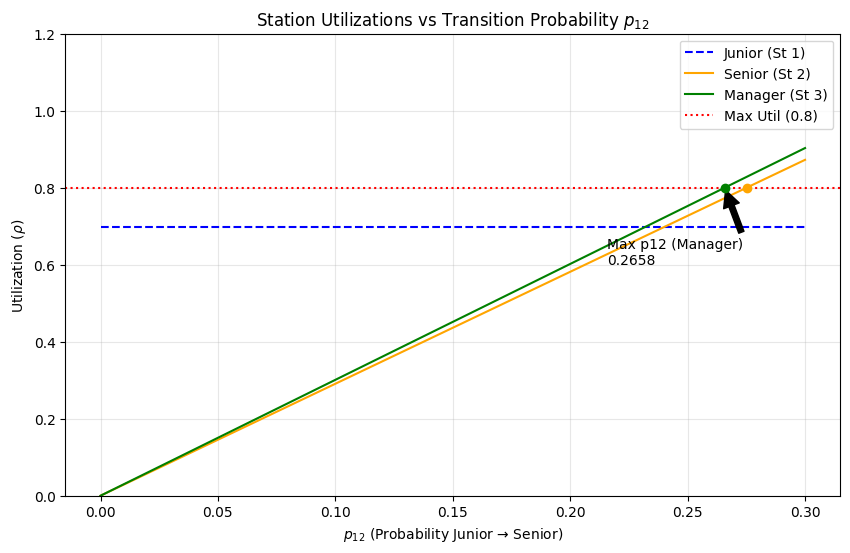

In [102]:
# --- Plotting Logic ---
current_p12 = p12

# 1. Define range for p12 (expanded to cover the new solution area around 0.26)
p12_range = np.linspace(0, 0.30, 200)

# 2. Calculate utilizations for this range
# Junior utilization is constant (independent of p12)
rho1_vals = np.full_like(p12_range, rho_junior)

# Senior and Manager utilizations scale linearly with p12
# Logic: rho_new = rho_current * (p_new / p_current)
rho2_vals = rho_senior * (p12_range / current_p12)
rho3_vals = rho_manager * (p12_range / current_p12)

# 3. Create Plot
plt.figure(figsize=(10, 6))

# Plot lines
plt.plot(p12_range, rho1_vals, label='Junior (St 1)', color='blue', linestyle='--')
plt.plot(p12_range, rho2_vals, label='Senior (St 2)', color='orange')
plt.plot(p12_range, rho3_vals, label='Manager (St 3)', color='green')

# Add target line at 0.8
plt.axhline(y=0.8, color='red', linestyle=':', label='Max Util (0.8)')

# Mark the intersection points (using variables from corrected Q3)
plt.scatter([max_p12_manager_limit], [0.8], color='green', zorder=5)
plt.scatter([max_p12_senior_limit], [0.8], color='orange', zorder=5)

# Annotate the critical point (Manager constraint)
plt.annotate(f'Max p12 (Manager)\n{max_p12_manager_limit:.4f}', 
             xy=(max_p12_manager_limit, 0.8), 
             xytext=(max_p12_manager_limit - 0.05, 0.6), # Position text below/left for clarity
             arrowprops=dict(facecolor='black', shrink=0.05))

# Formatting
plt.title('Station Utilizations vs Transition Probability $p_{12}$')
plt.xlabel('$p_{12}$ (Probability Junior $\\to$ Senior)')
plt.ylabel('Utilization ($\\rho$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.2)  # Focused scale to see the 0.8 crossover clearly

plt.show()

# Q4

In [104]:
# ==========================================
# 1. Setup Simulation Parameters
# ==========================================
current_p_trans = p_trans.copy()
current_p_trans[0, 1] = final_max_p12 

# Simulation Config
SIM_TIME = 20000
N_SAMPLES = 100000 

print(f"--- Simulation Setup (Simplified Q4) ---")
print(f"Optimized p12: {current_p_trans[0, 1]:.4f}")
print(f"Sim Time: {SIM_TIME}")

# ==========================================
# 2. Generate Random Variates
# ==========================================
# We wrap parameters in np.matrix() to ensure correct shape (1xN) for Butools

# Arrivals
arrivals_samples = np.array(SamplesFromPH(
    np.matrix(alpha_junior_arr), 
    np.matrix(S_junior_arr), 
    N_SAMPLES
))

# Services
service_samples = [
    np.array(SamplesFromPH(np.matrix(alpha_junior_srv), np.matrix(S_junior_srv), N_SAMPLES)),
    np.array(SamplesFromPH(np.matrix(alpha_senior_srv), np.matrix(S_senior_srv), N_SAMPLES)),
    np.array(SamplesFromPH(np.matrix(alpha_manager_srv), np.matrix(S_manager_srv), N_SAMPLES))
]

# Define Entry Point (Station 0)
arrival_rates_conf = np.array([1, 0, 0]) 

# ==========================================
# 3. Initialize and Run Existing Class
# ==========================================
network_sim = Queue_open_network_markov_trans(
    arrivals=arrivals_samples,
    services=service_samples,
    probs=current_p_trans,
    arrival_rates=arrival_rates_conf,
    sim_time=SIM_TIME,
    df_event_track=False 
)

print("Running simulation using project.py class...")
network_sim.run()
print("Simulation completed.")

# ==========================================
# 4. Extract and Print Queue Statistics
# ==========================================
print("\n--- Simulation Results (Average Queue Lengths) ---")
station_names = {0: "Junior", 1: "Senior", 2: "Manager"}

for i in range(3):
    # pmf[k] is prob of k customers in system
    pmf = network_sim.get_steady_single_station(i)
    
    # Avg Number in System (L)
    k_values = np.arange(len(pmf))
    avg_L = np.sum(k_values * pmf)
    
    # Utilization (rho) = 1 - P(Empty)
    rho = 1.0 - pmf[0]
    
    # Avg Queue Length (Lq) = L - rho
    avg_Lq = avg_L - rho
    
    print(f"{station_names[i]:<10}: {avg_Lq:.4f}")

--- Simulation Setup (Simplified Q4) ---
Optimized p12: 0.2658
Sim Time: 20000
Running simulation using project.py class...
Starting simulating open network...
Simulation end
Simulation completed.

--- Simulation Results (Average Queue Lengths) ---
Junior    : 3.7497
Senior    : 2.7355
Manager   : 6.3801


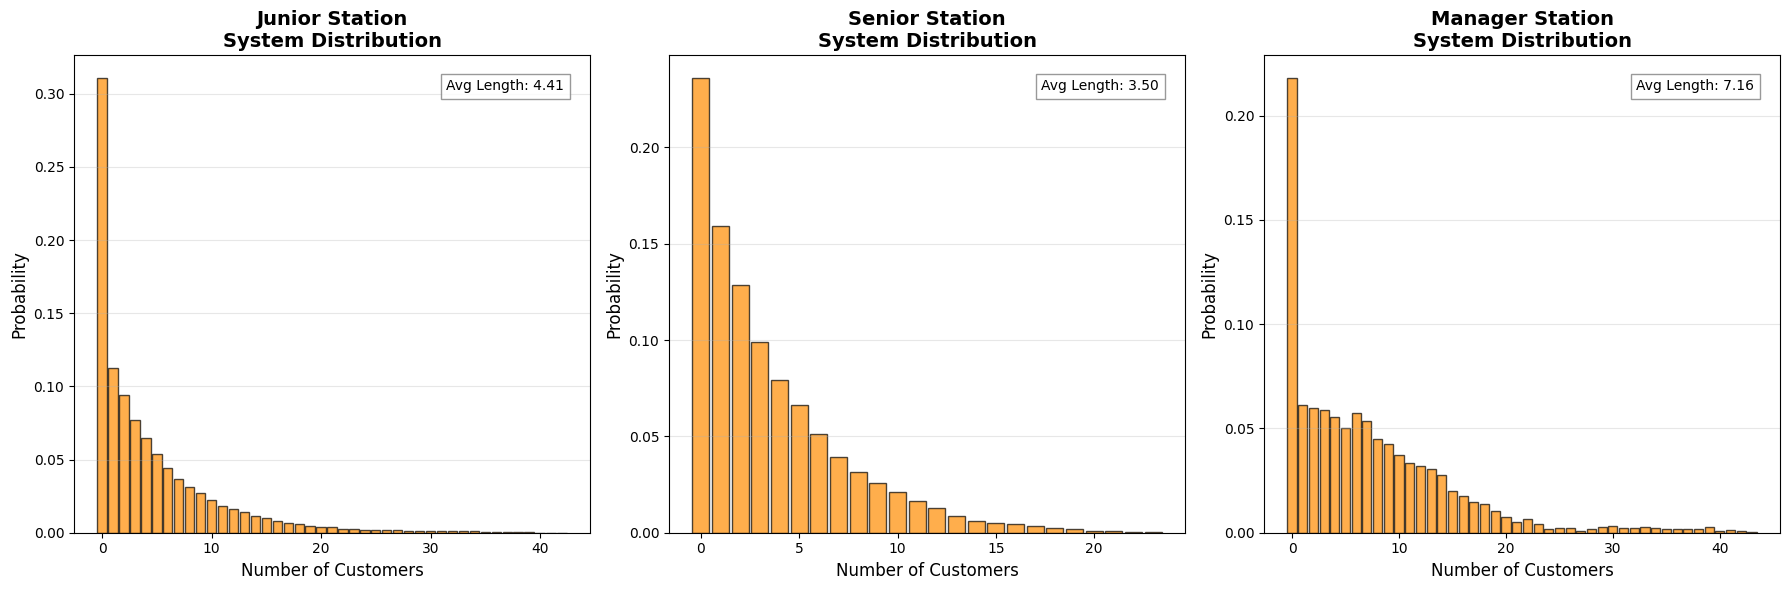

In [105]:
# ==========================================
# Visualize System Length Distributions
# ==========================================

station_names = {0: "Junior", 1: "Senior", 2: "Manager"}

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for station_idx, ax in enumerate(axes):
    # 1. Get the Steady-State Probabilities (PMF) directly from the class
    # This returns an array where index k = probability of k customers in system
    pmf = network_sim.get_steady_single_station(station_idx)
    
    # 2. Filter data for plotting
    # We only plot up to a probability < 0.0001 to keep the graph readable
    # (The array size is 500,000, we don't want to plot all empty zeros)
    max_k = np.where(pmf > 1e-4)[0][-1] + 1 
    states = np.arange(max_k)
    probs = pmf[:max_k]
    
    # 3. Plot Bar Chart (Since we have probabilities, not raw counts)
    # Set color to 'orange' for all stations
    ax.bar(states, probs, color='darkorange', alpha=0.7, edgecolor='black', width=0.85)
    
    # Formatting
    ax.set_title(f"{station_names[station_idx]} Station\nSystem Distribution", fontsize=14, fontweight='bold')
    ax.set_xlabel("Number of Customers", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    # Add Average Length Annotation
    # Expected Value E[L] = Sum(k * p_k)
    avg_len = np.sum(states * probs)
    ax.text(0.95, 0.95, f"Avg Length: {avg_len:.2f}", 
            transform=ax.transAxes, ha='right', va='top', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

# Q5

In [38]:
# ==========================================
# Q5: Find Required Simulation Time (Clean Output)
# ==========================================

# Configuration
target_width = 0.5
current_sim_time = 10000
step_size = 2000
num_runs = 10
max_steps = 10 

# Define Entry Point (Station 0)
arrival_rates_conf = np.array([1, 0, 0]) 

# Print Header
print(f"{'Sim Time':<15} | {'Mean Sojourn':<15} | {'CI Width':<15} | {'Status'}")
print("-" * 65)

found = False
final_sim_time = 0

for step in range(max_steps):
    run_averages = []
    
    # Run 10 independent replications
    for _ in range(num_runs):
        # Initialize Network
        network = Queue_open_network_markov_trans(
            arrivals=arrivals_samples,
            services=service_samples,
            probs=current_p_trans,
            arrival_rates=arrival_rates_conf,
            sim_time=current_sim_time,
            df_event_track=False
        )
        
        # Run Simulation SILENTLY
        # We redirect stdout to a dummy buffer to catch the print statements
        with contextlib.redirect_stdout(io.StringIO()):
            network.run()
        
        # Collect Mean Sojourn for this run
        run_averages.append(np.mean(network.sojourn_tot))

    
    # Calculate Statistics
    width = give_CI_length(run_averages)
    grand_mean = np.mean(run_averages)
    
    # Determine Status
    if width <= target_width:
        status = "OK"
        found = True
        final_sim_time = current_sim_time
    else:
        status = "Too Wide"
    
    # Print formatted row
    print(f"{current_sim_time:<15} | {grand_mean:<15.4f} | {width:<15.4f} | {status}")
    
    # Stop immediately if found
    if found:
        break
        
    # Increment time for next step
    current_sim_time += step_size

print("-" * 65)
if found:
    print(f"Result: The required simulation time is {final_sim_time}")
else:
    print("Result: Could not satisfy CI width within maximum steps.")

Sim Time        | Mean Sojourn    | CI Width        | Status
-----------------------------------------------------------------
10000           | 4.5590          | 0.7456          | Too Wide
12000           | 4.8342          | 0.8457          | Too Wide
14000           | 4.8584          | 0.8092          | Too Wide
16000           | 4.8299          | 0.6195          | Too Wide
18000           | 4.8114          | 0.8571          | Too Wide
20000           | 5.2325          | 0.8546          | Too Wide
22000           | 5.0464          | 0.6332          | Too Wide
24000           | 4.9665          | 0.6826          | Too Wide
26000           | 4.8967          | 0.7697          | Too Wide
28000           | 4.8120          | 0.6198          | Too Wide
-----------------------------------------------------------------
Result: Could not satisfy CI width within maximum steps.


# Q6+7

--- Configuration ---
Original Max p12: 0.26577
New Reduced p12:  0.23577 (Reduced by 0.03)
Running simulation with new p12...
Starting simulating open network...
Simulation end
Simulation completed.


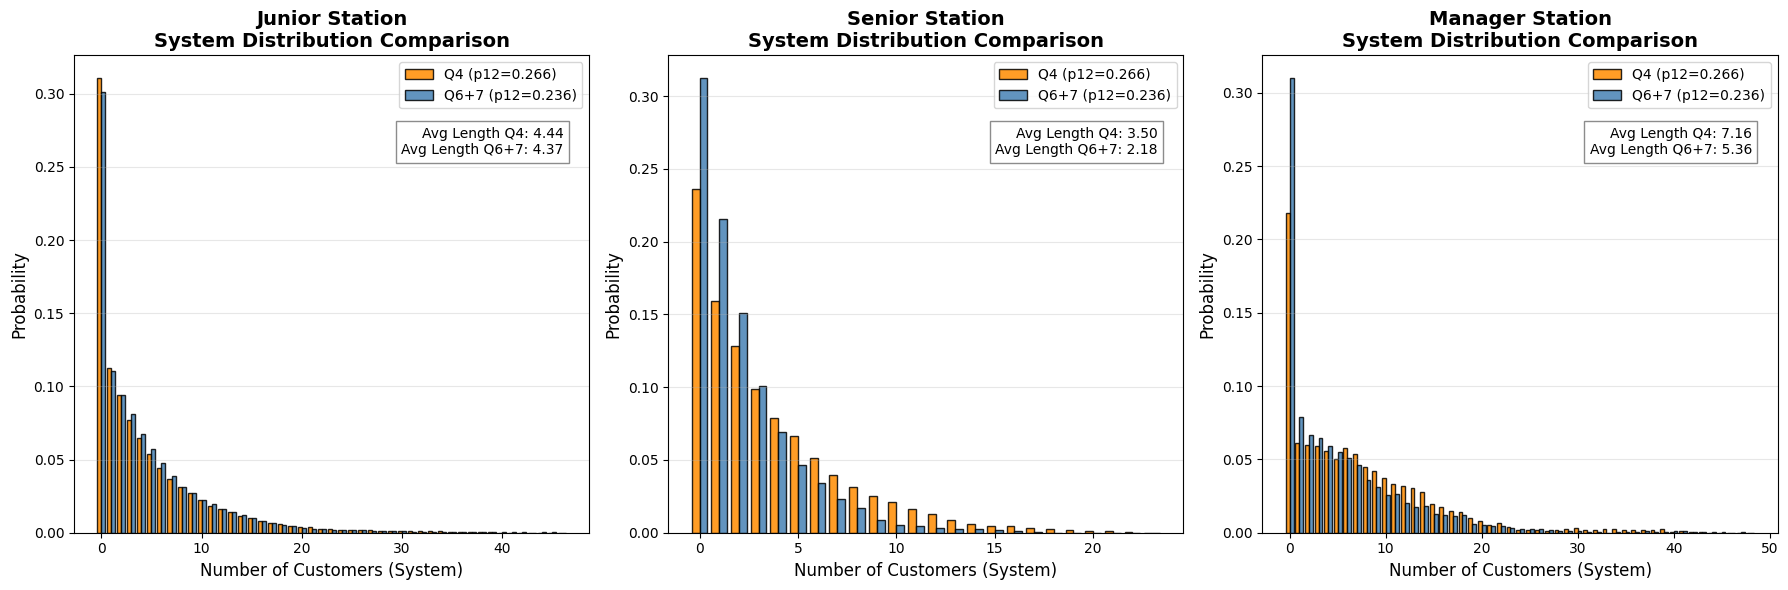

In [106]:
# ==========================================
# 1. Adjust Transition Probability
# ==========================================
reduction_amount = 0.03
new_p12 = final_max_p12 - reduction_amount

# Create a new transition matrix
p_trans_new = p_trans.copy()
p_trans_new[0, 1] = new_p12

print(f"--- Configuration ---")
print(f"Original Max p12: {final_max_p12:.5f}")
print(f"New Reduced p12:  {new_p12:.5f} (Reduced by {reduction_amount})")

# ==========================================
# 2. Run Simulation (New Scenario)
# ==========================================
SIM_TIME = 20000
arrival_rates_conf = np.array([1, 0, 0])

# Initialize the Network
network_new = Queue_open_network_markov_trans(
    arrivals=arrivals_samples,  
    services=service_samples,   
    probs=p_trans_new,          
    arrival_rates=arrival_rates_conf,
    sim_time=SIM_TIME,
    df_event_track=False
)

print(f"Running simulation with new p12...")
network_new.run()
print("Simulation completed.")

# ==========================================
# 3. Plot Queue Length Distributions (Comparison Q4 vs Q6+7)
# ==========================================
station_names = {0: "Junior", 1: "Senior", 2: "Manager"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for station_idx, ax in enumerate(axes):
    # Get Steady-State Probabilities from BOTH simulations
    pmf_q4 = network_sim.get_steady_single_station(station_idx)
    pmf_new = network_new.get_steady_single_station(station_idx)
    
    # Filter for plotting: find the max 'k' state we actually care about plotting
    max_k_q4 = np.where(pmf_q4 > 1e-4)[0][-1] + 1 if len(np.where(pmf_q4 > 1e-4)[0]) > 0 else 1
    max_k_new = np.where(pmf_new > 1e-4)[0][-1] + 1 if len(np.where(pmf_new > 1e-4)[0]) > 0 else 1
    max_k = max(max_k_q4, max_k_new)
    
    states = np.arange(max_k)
    probs_q4 = pmf_q4[:max_k]
    probs_new = pmf_new[:max_k]
    
    # Plot Grouped Bar Chart with High Contrast Colors
    width = 0.4
    ax.bar(states - width/2, probs_q4, color='darkorange', alpha=0.85, edgecolor='black', width=width, label=f"Q4 (p12={final_max_p12:.3f})")
    ax.bar(states + width/2, probs_new, color='steelblue', alpha=0.85, edgecolor='black', width=width, label=f"Q6+7 (p12={new_p12:.3f})")
    
    # Formatting
    ax.set_title(f"{station_names[station_idx]} Station\nSystem Distribution Comparison", fontsize=14, fontweight='bold')
    ax.set_xlabel("Number of Customers (System)", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    
    # Calculate & Add Average Length Annotation
    avg_len_q4 = np.sum(np.arange(len(pmf_q4)) * pmf_q4)
    avg_len_new = np.sum(np.arange(len(pmf_new)) * pmf_new)
    
    info_text = f"Avg Length Q4: {avg_len_q4:.2f}\nAvg Length Q6+7: {avg_len_new:.2f}"
    ax.text(0.95, 0.85, info_text, 
            transform=ax.transAxes, ha='right', va='top', 
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

Since p1,2 doens't effect the Junior station, its queue length stays almost the same. On the other side - looking on the Manager station, it is significant that the queue length has gone down. 

# Q8+9

--- Configuration ---
Mean Service Time: 0.1901
Exponential Rate (mu): 5.2609
Simulating New System (Exp Service)...
Starting simulating open network...
Simulation end


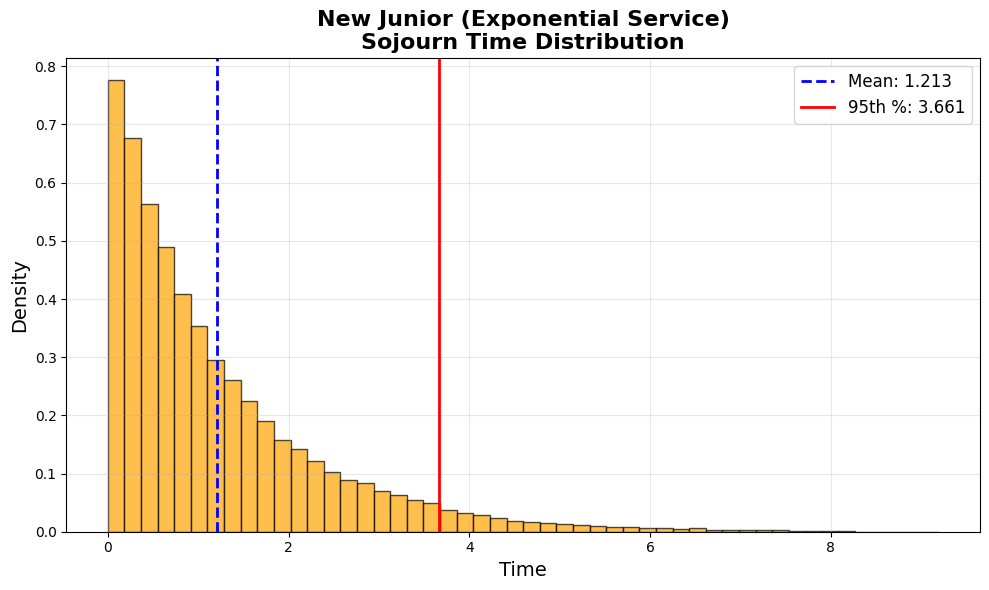

Original Junior Service Variance: 0.0367
New Junior Service Variance:      0.0361

The new junior service variance went a bit smaller, but is almost the same.
Because that is the only change in the system, it is slightly more likely
that the sojourn time went down, but not necessarily.


In [107]:
# ==========================================
# 1. Setup: Isolate Junior Station & Define Exponential
# ==========================================
butools.checkInput = False

# Create a transition matrix where customers leave immediately after Junior station
p_trans_isolated = p_trans.copy()
p_trans_isolated[0, 1] = 0.0  # p12 = 0 implies 100% exit probability

# Calculate Mean Service Time from the fitted PH (to match with Exponential)
# (Assuming variables alpha_junior_srv, S_junior_srv exist from Q1)
mean_service_junior = compute_first_n_moments(alpha_junior_srv, S_junior_srv, 1)[0]
mu_junior = 1.0 / mean_service_junior

# Calculate variances for comparison text at the end
moments_ph = compute_first_n_moments(alpha_junior_srv, S_junior_srv, 2)
var_service_ph = moments_ph[1] - (moments_ph[0]**2)
var_service_exp = mean_service_junior**2

# Define Exponential as PH of size 1 for generation
alpha_exp = np.matrix([1.0])
S_exp = np.matrix([[-mu_junior]])

print(f"--- Configuration ---")
print(f"Mean Service Time: {mean_service_junior:.4f}")
print(f"Exponential Rate (mu): {mu_junior:.4f}")

# ==========================================
# 2. Generate Random Variates
# ==========================================
SIM_TIME = 20000
N_SAMPLES = 100000 

# Service Times:
# Station 0: New Exponential Distribution
# Station 1 & 2: Original PH
service_samples_exp = [
    np.array(SamplesFromPH(alpha_exp, S_exp, N_SAMPLES)),
    service_samples[1],
    service_samples[2]
]

# ==========================================
# 3. Run Simulation
# ==========================================
print("Simulating New System (Exp Service)...")
arrival_rates_conf = np.array([1, 0, 0])

network_exp = Queue_open_network_markov_trans(
    arrivals=arrivals_samples,
    services=service_samples_exp,
    probs=p_trans_isolated,     # Isolated (p12=0)
    arrival_rates=arrival_rates_conf,
    sim_time=SIM_TIME,
    df_event_track=False
)

network_exp.run()

# Extract Sojourn Times
# The class stores total system time in .sojourn_tot
sojourn_exponential = np.array(network_exp.sojourn_tot)

# ==========================================
# 4. Analysis & Plotting
# ==========================================

# Calculate Statistics
mean_new = np.mean(sojourn_exponential)
pct95_new = np.percentile(sojourn_exponential, 95)
var_new = np.var(sojourn_exponential)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(sojourn_exponential, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(mean_new, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_new:.3f}')
plt.axvline(pct95_new, color='red', linestyle='-', linewidth=2, label=f'95th %: {pct95_new:.3f}')

plt.title("New Junior (Exponential Service)\nSojourn Time Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Time", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print Analysis
print(f'Original Junior Service Variance: {var_service_ph:.4f}')
print(f'New Junior Service Variance:      {var_service_exp:.4f}')
print(
    "\n"
    "The new junior service variance went a bit smaller, but is almost the same.\n"
    "Because that is the only change in the system, it is slightly more likely\n"
    "that the sojourn time went down, but not necessarily."
)

# Q10

In [108]:
# ==========================================
# Q10: Willingness to Pay Calculation
# ==========================================
SIM_TIME = 20000
arrival_rates_conf = np.array([1, 0, 0])

# 1. Run Baseline Simulation (Current System)
# ---------------------------------------------------------
print("--- Calculating Baseline Sojourn Time ---")

# Setup Baseline: Original PH Service Times + Original Transition Matrix
# We use 'service_samples' (from Q4) and 'p_trans' (the original matrix)
network_base = Queue_open_network_markov_trans(
    arrivals=arrivals_samples,
    services=service_samples,
    probs=p_trans,          
    arrival_rates=arrival_rates_conf,
    sim_time=SIM_TIME,
    df_event_track=False
)

network_base.run()

# Calculate average sojourn time (W)
W_current = np.mean(network_base.sojourn_tot)


# 2. Run Improved Simulation (New Junior, p12 = 0)
# ---------------------------------------------------------
print("--- Calculating Improved Sojourn Time (p12=0) ---")

# Setup Improved: Exponential Junior Service + Isolated Transition
# We use 'service_samples_exp' (from Q8) and 'p_trans_isolated' (from Q8)
network_improved = Queue_open_network_markov_trans(
    arrivals=arrivals_samples,
    services=service_samples_exp,
    probs=p_trans_isolated, # p12 = 0
    arrival_rates=arrival_rates_conf,
    sim_time=SIM_TIME,
    df_event_track=False
)

network_improved.run()

# Calculate new average sojourn time
W_new = np.mean(network_improved.sojourn_tot)


# 3. Calculate Financial Value
# ---------------------------------------------------------
delta_W = W_current - W_new
value_per_unit = 30000
total_willingness_to_pay = delta_W * value_per_unit

print("-" * 40)
print(f"Current Avg Sojourn Time (W): {W_current:.4f}")
print(f"New Avg Sojourn Time (W'):    {W_new:.4f}")
print(f"Time Saved (Delta):           {delta_W:.4f}")
print("-" * 40)
print(f"Willingness to Pay (Approximately):           {total_willingness_to_pay:,.2f} NIS")

--- Calculating Baseline Sojourn Time ---
Starting simulating open network...
Simulation end
--- Calculating Improved Sojourn Time (p12=0) ---
Starting simulating open network...
Simulation end
----------------------------------------
Current Avg Sojourn Time (W): 5.1018
New Avg Sojourn Time (W'):    1.1536
Time Saved (Delta):           3.9482
----------------------------------------
Willingness to Pay (Approximately):           118,447.49 NIS


# Q11

In [118]:
sys.modules['numpy._core'] = sys.modules['numpy.core']
sys.modules['numpy._core.multiarray'] = sys.modules['numpy.core.multiarray']

Service Rate (mu)    | Max P(L >= 5)        | Status
------------------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:25<00:00, 99.76it/s]


1.50                 | 0.0904               | Too High


100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:27<00:00, 91.84it/s]


1.70                 | 0.0648               | Too High


...

1.90                 | 0.0444               | Too High


100%|█████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:24<00:00, 101.87it/s]


2.10                 | 0.0316               | Too High


100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:27<00:00, 92.58it/s]


2.30                 | 0.0208               | OK
------------------------------------------------------------
Stopping early: Found satisfactory rate mu = 2.30


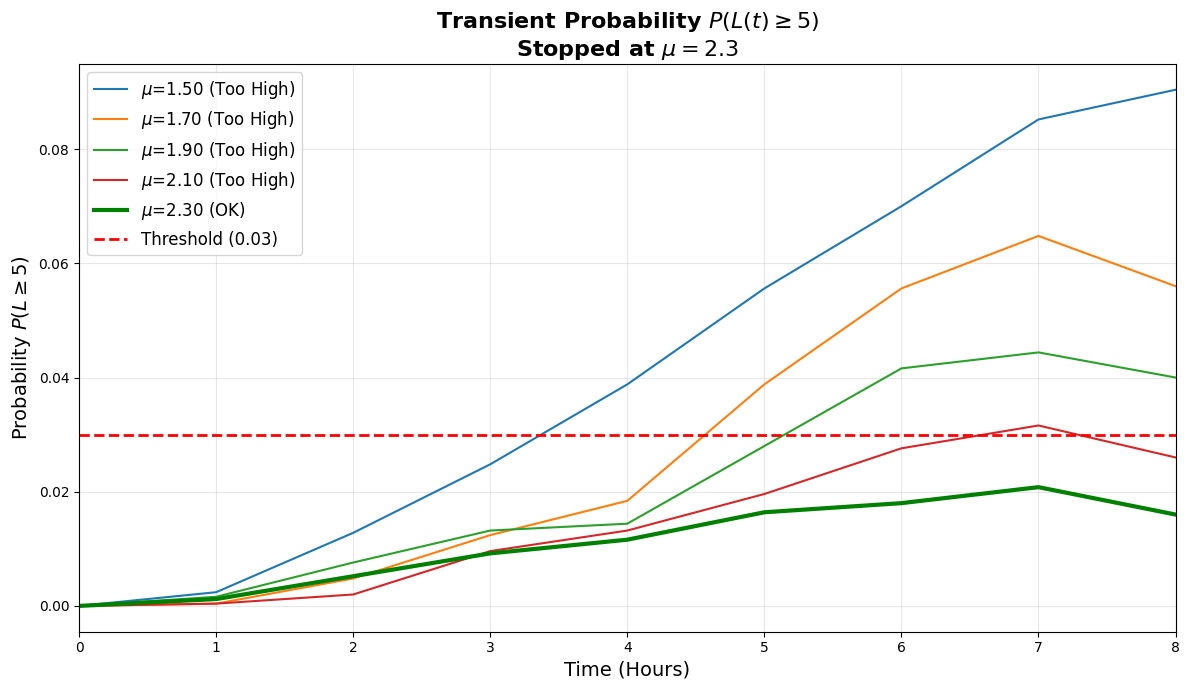

In [119]:
# ==========================================
# Find Minimal Service Rate (Stop on Success)
# ==========================================

# --- 1. Parameters ---
# We test from 1.5 up to 2.5
mu_values_to_test = np.arange(1.5, 2.5, 0.2) 
sim_time_hours = 8
threshold_prob = 0.03
target_k = 5 

# --- 2. Run & Plot ---
plt.figure(figsize=(12, 7))
minimal_valid_mu = None

print(f"{'Service Rate (mu)':<20} | {'Max P(L >= 5)':<20} | {'Status'}")
print("-" * 60)

for mu in mu_values_to_test:
    # Run Simulation
    res_matrix = give_transeint_probs(arrival_scd_pd, mu, sim_time_hours)
    
    # Calculate Probabilities
    prob_ge_5_over_time = res_matrix[:, target_k:].sum(axis=1)
    time_axis = np.linspace(0, sim_time_hours, res_matrix.shape[0])
    
    # Check Constraint
    max_prob = np.max(prob_ge_5_over_time)
    is_valid = max_prob <= threshold_prob
    status = "OK" if is_valid else "Too High"
    
    # Plot this run
    color = 'green' if is_valid else None 
    width = 3 if is_valid else 1.5
    # Use raw string r'' to prevent escape character issues
    plt.plot(time_axis, prob_ge_5_over_time, label=rf'$\mu$={mu:.2f} ({status})', linewidth=width, color=color)
    
    print(f"{mu:<20.2f} | {max_prob:<20.4f} | {status}")
    
    # STOP if we found a valid mu
    if is_valid:
        minimal_valid_mu = mu
        print("-" * 60)
        print(f"Stopping early: Found satisfactory rate mu = {mu:.2f}")
        break

# --- 3. Formatting ---
plt.axhline(y=threshold_prob, color='r', linestyle='--', linewidth=2, label=f'Threshold ({threshold_prob})')

if minimal_valid_mu:
    plt.title(rf"Transient Probability $P(L(t) \geq {target_k})$" + "\n" + rf"Stopped at $\mu={minimal_valid_mu}$", fontsize=16, fontweight='bold')
else:
    plt.title(rf"Transient Probability $P(L(t) \geq {target_k})$", fontsize=16, fontweight='bold')

plt.xlabel("Time (Hours)", fontsize=14)
plt.ylabel(rf"Probability $P(L \geq {target_k})$", fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, sim_time_hours)
plt.tight_layout()
plt.show()